# Import Required Libraries 

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load Dataset
raw = pd.read_excel("bankruptcy-prevention (1).xlsx",header=None)

In [4]:
# Extract the first column and split using ';'
data = raw.iloc[:,0].str.split(';', expand=True)

# Rename columns
data.columns = data.iloc[0]

# Remove first row
data = data.iloc[1:].reset_index(drop=True)

In [5]:
# Rename target column
data.columns = [
    "industrial_risk",
    "management_risk",
    "financial_flexibility",
    "credibility",
    "competitiveness",
    "operating_risk",
    "class"
]


In [6]:
data.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy


In [7]:
# Dataset Shape

print("Rows :", data.shape[0])
print("Columns :", data.shape[1])

    


Rows : 250
Columns : 7


In [8]:
# Display Dataset 
data.head()


,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy


In [9]:
# Display Last Five Records 
data.tail()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
245,0,1,1,1,1,1,non-bankruptcy
246,1,1,0.5,1,1,0,non-bankruptcy
247,0,1,1,0.5,0.5,0,non-bankruptcy
248,1,0,0.5,1,0.5,0,non-bankruptcy
249,1,0,0.5,0.5,1,1,non-bankruptcy


In [10]:
data.sample(5)

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
3,0.5,0,0,0.5,0,1,bankruptcy
196,0.5,0.5,0.5,1,1,0.5,non-bankruptcy
25,0.5,0.5,0,0,0,1,bankruptcy
139,0,1,1,0.5,0.5,0,non-bankruptcy
42,1,1,0,0.5,0,0,bankruptcy


In [11]:
# Dataset Information 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   industrial_risk        250 non-null    object
 1   management_risk        250 non-null    object
 2   financial_flexibility  250 non-null    object
 3   credibility            250 non-null    object
 4   competitiveness        250 non-null    object
 5   operating_risk         250 non-null    object
 6   class                  250 non-null    object
dtypes: object(7)
memory usage: 13.8+ KB


In [12]:
# Convert Numerical Columns
num_cols = data.columns[:-1]

for col in num_cols:
    data[col] = data[col].astype(float)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        250 non-null    float64
 1   management_risk        250 non-null    float64
 2   financial_flexibility  250 non-null    float64
 3   credibility            250 non-null    float64
 4   competitiveness        250 non-null    float64
 5   operating_risk         250 non-null    float64
 6   class                  250 non-null    object 
dtypes: float64(6), object(1)
memory usage: 13.8+ KB


In [13]:
# Check Missing Values 
data.isnull().sum()


industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64

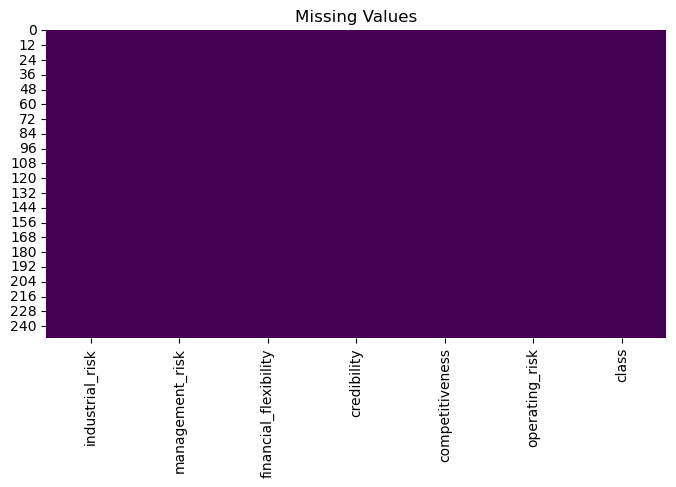

In [14]:
plt.figure(figsize=(8,4))
sns.heatmap(data.isnull(),cbar=False,cmap='viridis')
plt.title("Missing Values")
plt.show()

In [15]:
# Duplicates Values 
print("Duplicate Rows :",data.duplicated().sum())

Duplicate Rows : 147


In [16]:
data = data.drop_duplicates()

In [17]:
# Statistical Summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
industrial_risk,103.0,0.485437,0.404971,0.0,0.0,0.5,1.0,1.0
management_risk,103.0,0.563107,0.412308,0.0,0.0,0.5,1.0,1.0
financial_flexibility,103.0,0.504854,0.405206,0.0,0.0,0.5,1.0,1.0
credibility,103.0,0.582524,0.377668,0.0,0.5,0.5,1.0,1.0
competitiveness,103.0,0.640777,0.410747,0.0,0.5,1.0,1.0,1.0
operating_risk,103.0,0.514563,0.439788,0.0,0.0,0.5,1.0,1.0


In [18]:
# Target Variable Distribution
data['class'].value_counts()


class
non-bankruptcy    78
bankruptcy        25
Name: count, dtype: int64

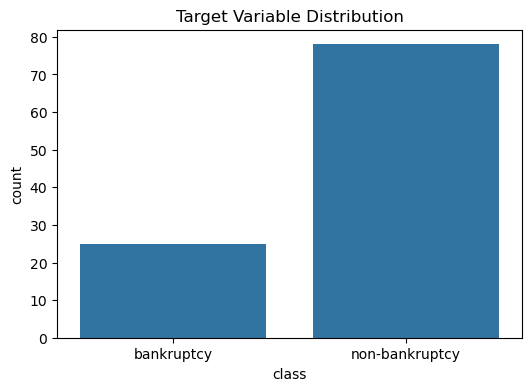

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x='class',data=data)

plt.title("Target Variable Distribution")

plt.show()

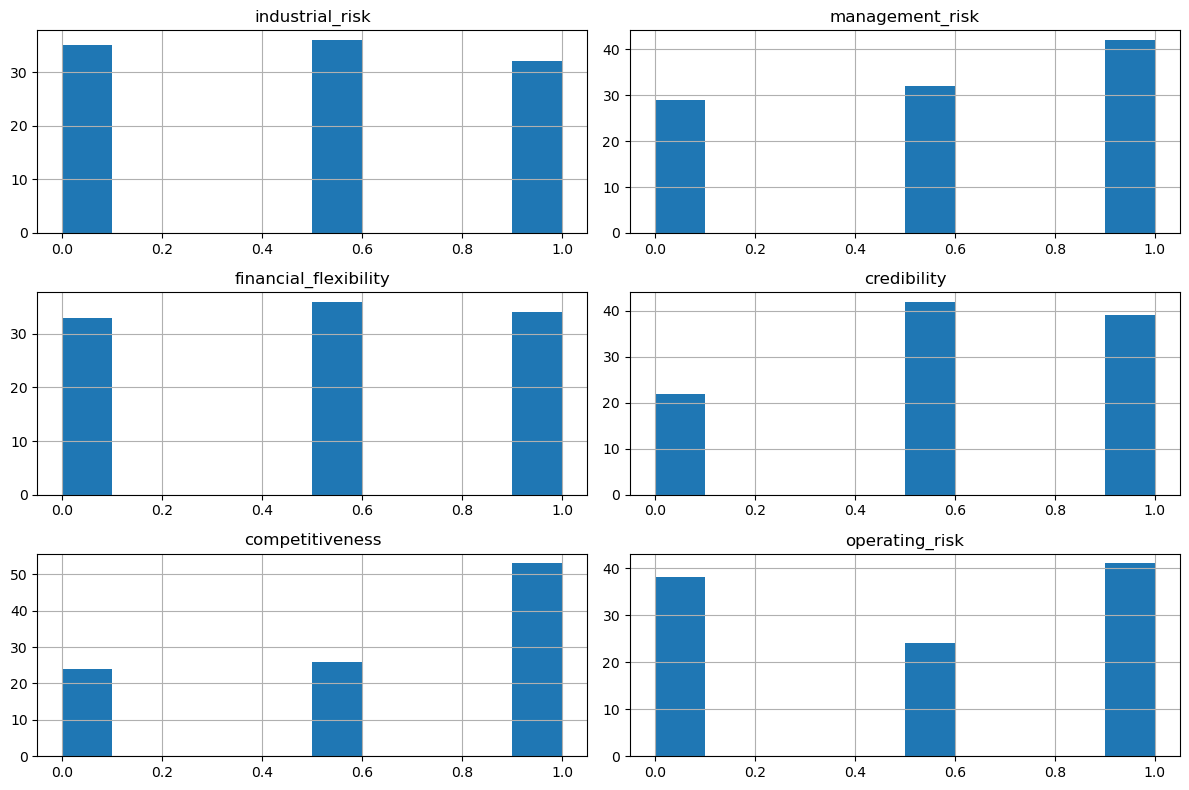

In [20]:
# Numerical Feature Distribution
data.hist(figsize=(12,8),bins=10)

plt.tight_layout()

plt.show()

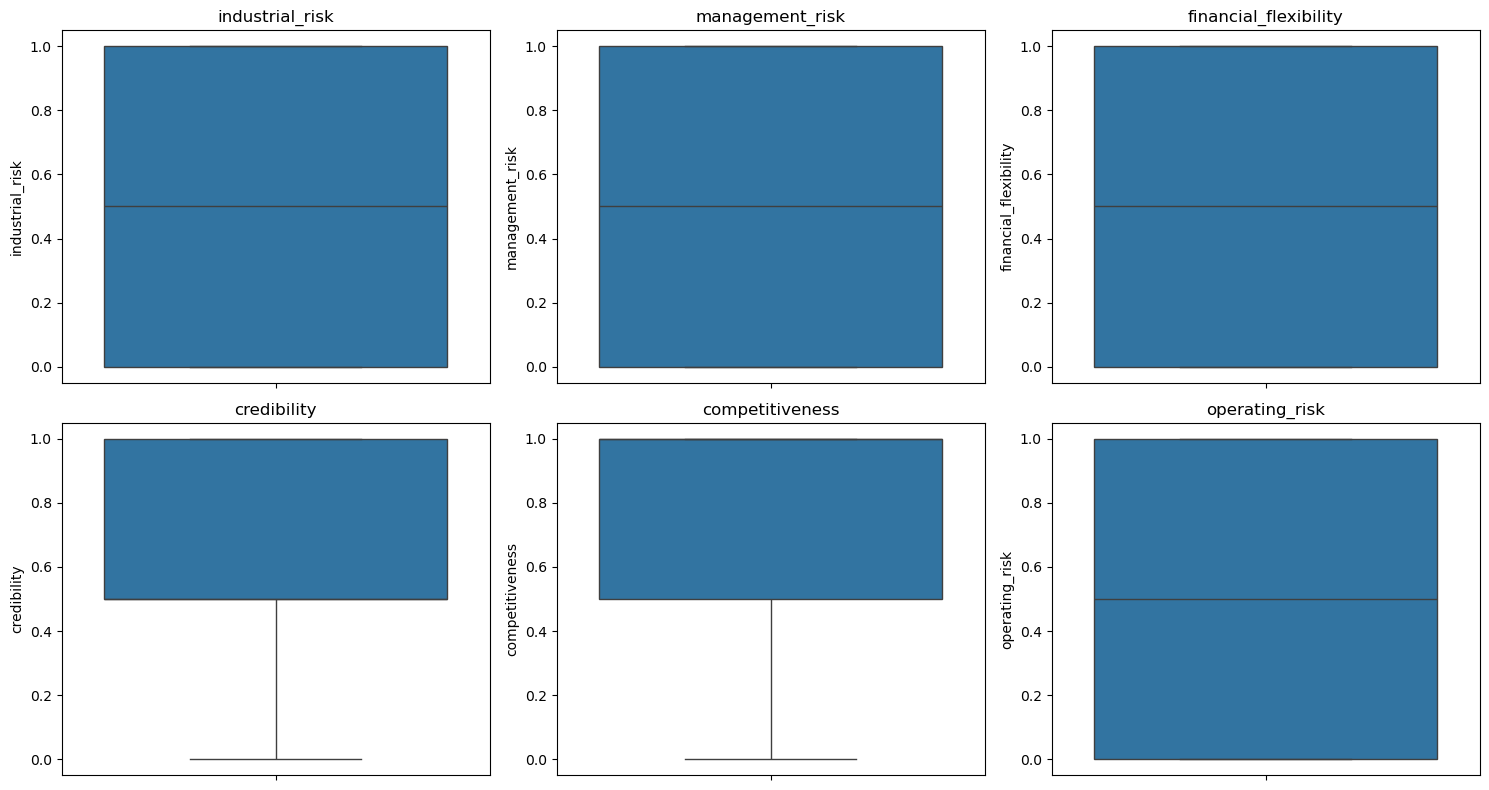

In [21]:
# Boxplots(Outlier Detection)
plt.figure(figsize=(15,8))
for i,col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [22]:
# Unique Values
for col in data.columns:
    print(col)
    print(data[col].value_counts())
    print("-"*40)

industrial_risk
industrial_risk
0.5    36
0.0    35
1.0    32
Name: count, dtype: int64
----------------------------------------
management_risk
management_risk
1.0    42
0.5    32
0.0    29
Name: count, dtype: int64
----------------------------------------
financial_flexibility
financial_flexibility
0.5    36
1.0    34
0.0    33
Name: count, dtype: int64
----------------------------------------
credibility
credibility
0.5    42
1.0    39
0.0    22
Name: count, dtype: int64
----------------------------------------
competitiveness
competitiveness
1.0    53
0.5    26
0.0    24
Name: count, dtype: int64
----------------------------------------
operating_risk
operating_risk
1.0    41
0.0    38
0.5    24
Name: count, dtype: int64
----------------------------------------
class
class
non-bankruptcy    78
bankruptcy        25
Name: count, dtype: int64
----------------------------------------


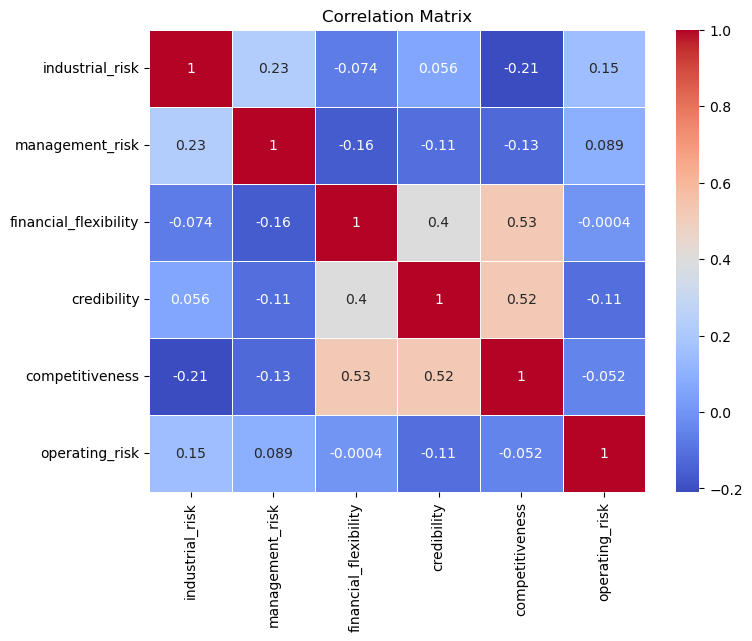

In [23]:
# Correlation Analysis
corr=data[num_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Matrix")

plt.show()

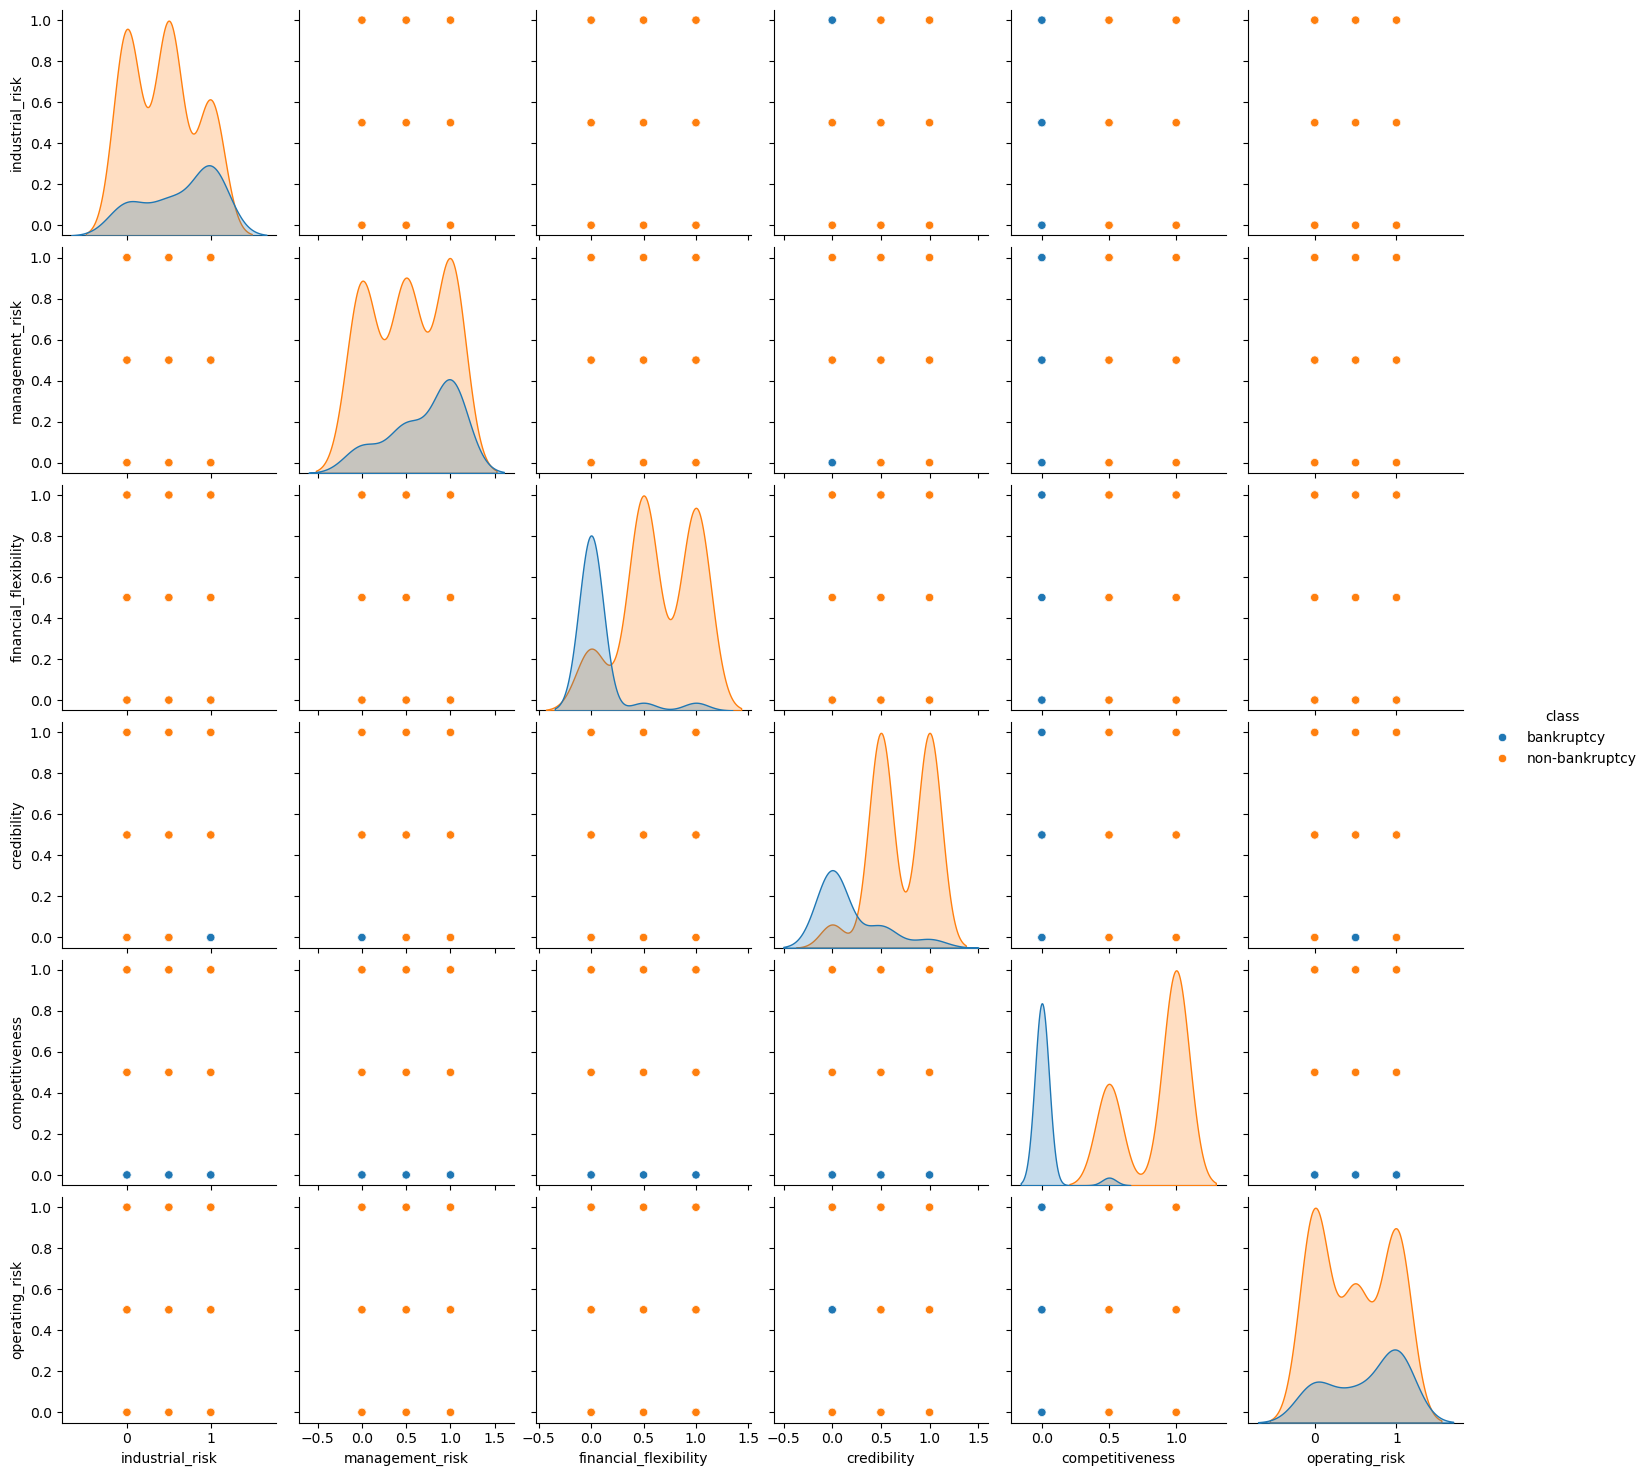

In [24]:
# Pairplot
sns.pairplot(data,hue='class')
plt.show()

In [25]:
# Class-wise Mean Analysis
data.groupby("class").mean()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk
class,,,,,,
bankruptcy,0.640000,0.700000,0.060000,0.180000,0.020000,0.620000
non-bankruptcy,0.435897,0.519231,0.647436,0.711538,0.839744,0.480769


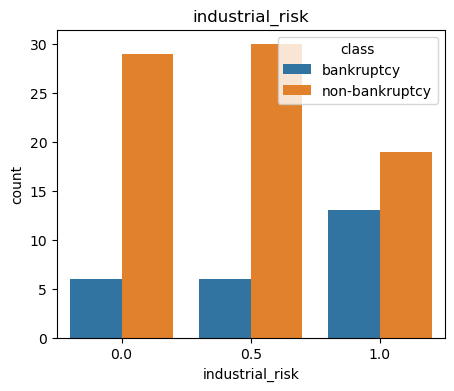

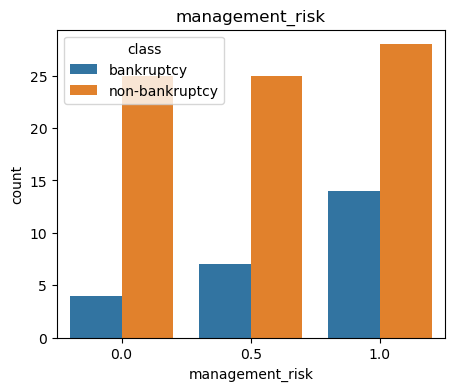

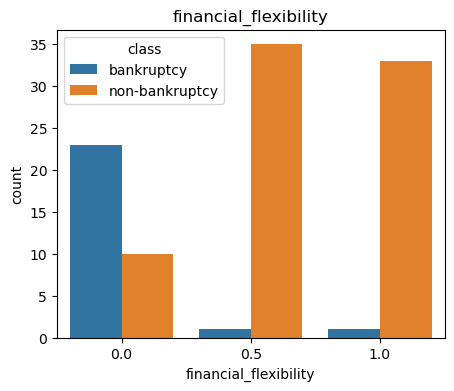

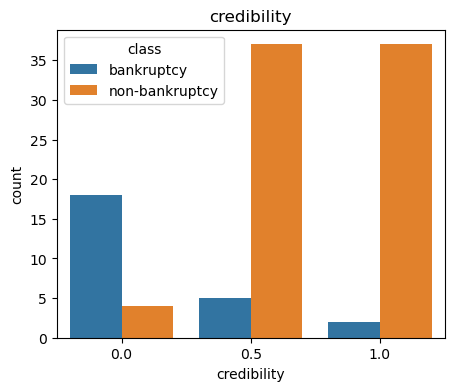

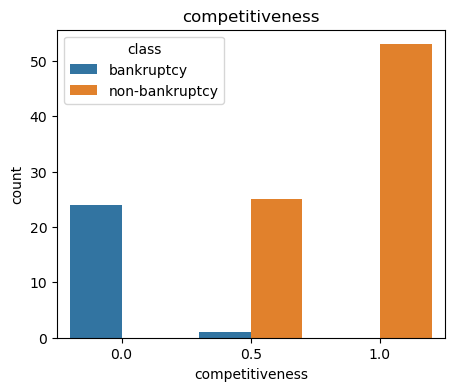

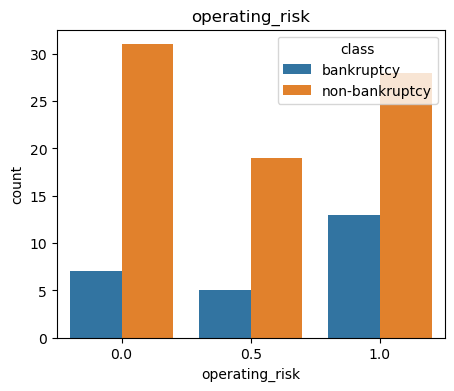

In [26]:
# Feature-Wise Comparison
for col in num_cols:

    plt.figure(figsize=(5,4))

    sns.countplot(x=col,hue='class',data=data)

    plt.title(col)

    plt.show()

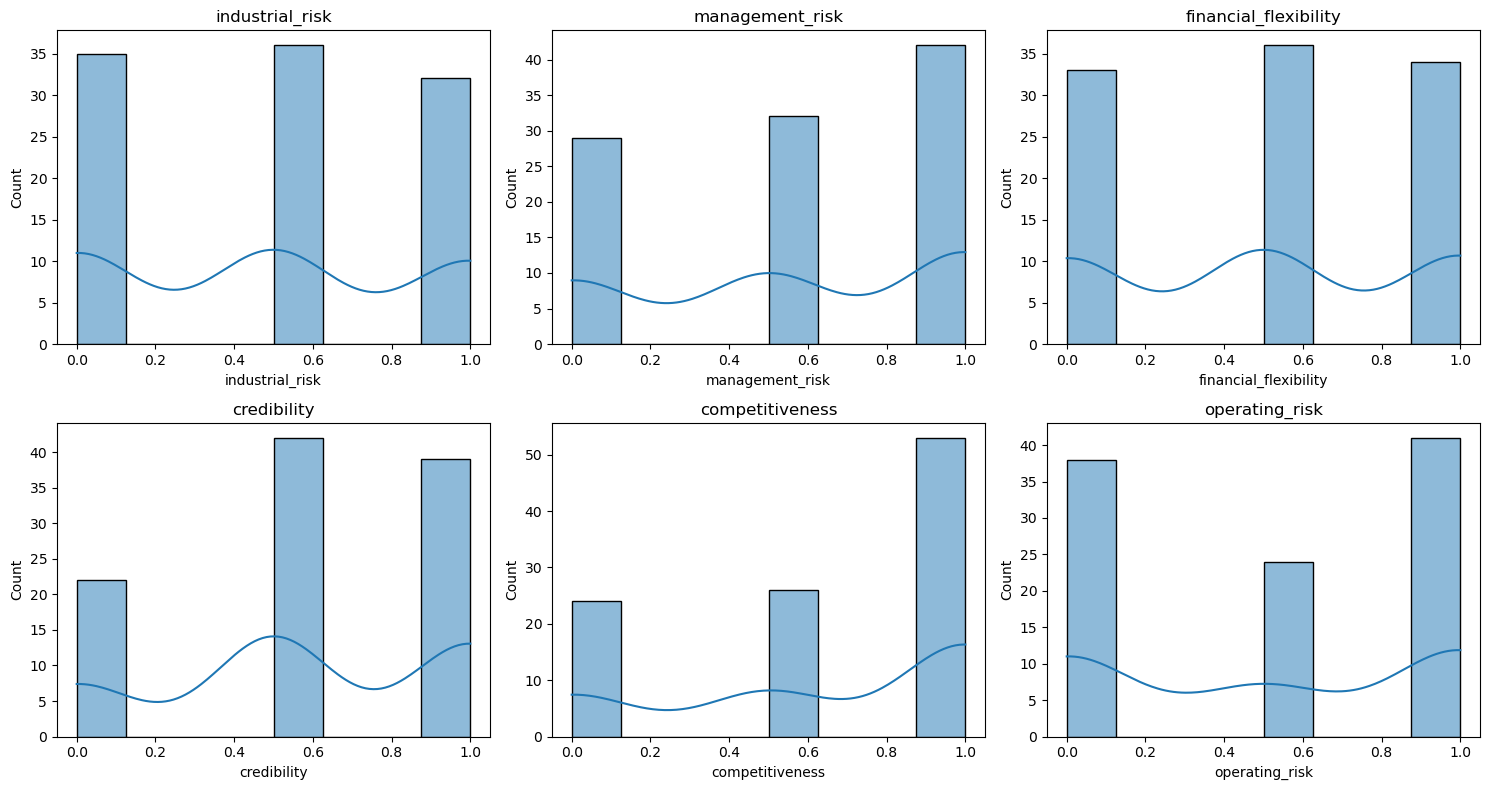

In [27]:
# Distribution Plots
plt.figure(figsize=(15,8))
for i,col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.histplot(data[col],kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

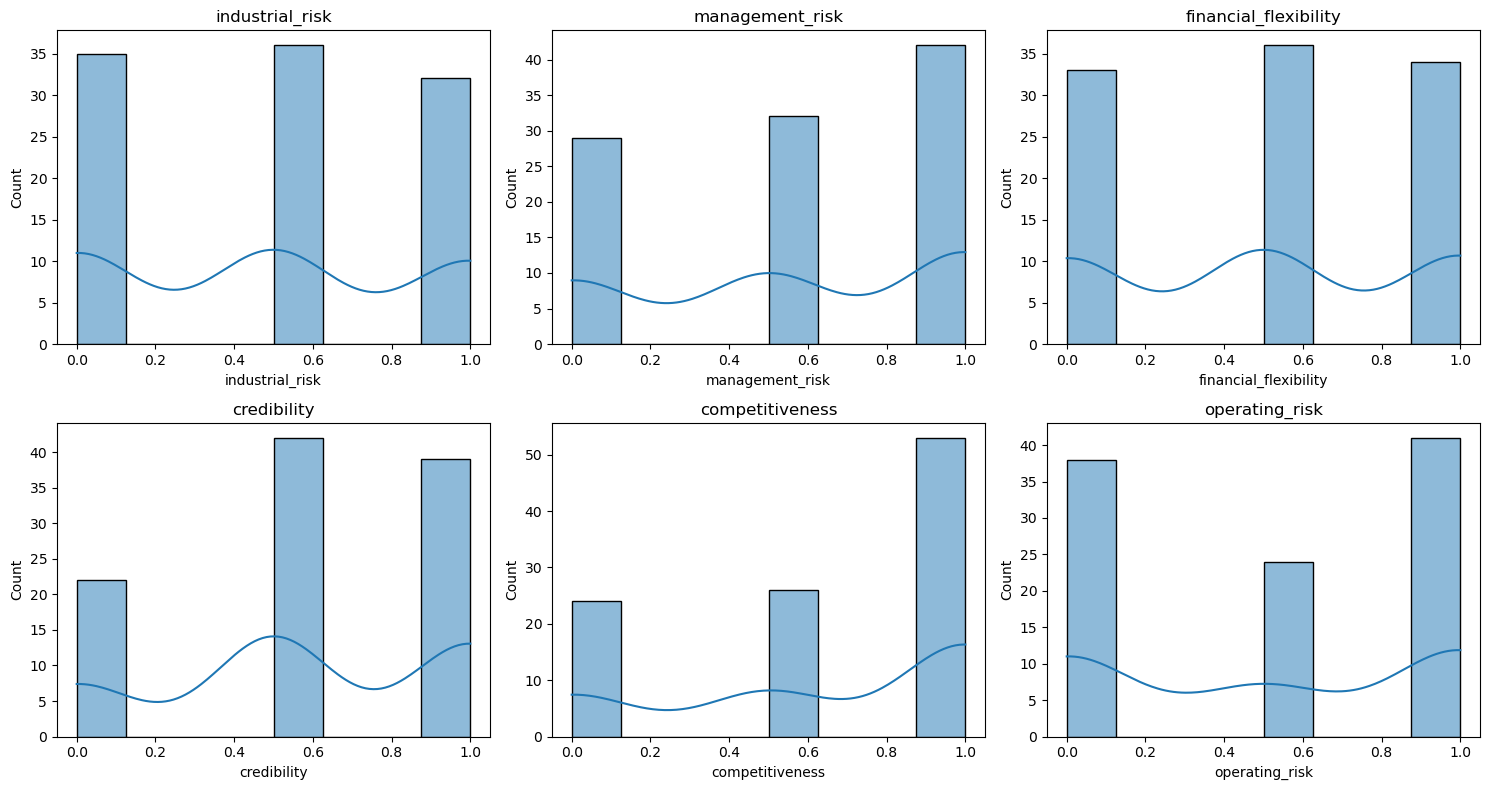

In [28]:
# Distribution Plots
plt.figure(figsize=(15,8))
for i ,col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.histplot(data[col],kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()


In [29]:
# Skewness
data[num_cols].skew()

industrial_risk          0.053615
management_risk         -0.240163
financial_flexibility   -0.017869
credibility             -0.284848
competitiveness         -0.567021
operating_risk          -0.057269
dtype: float64

In [30]:
# Class Percentage
(data['class'].value_counts(normalize=True)*100).round(2)

class
non-bankruptcy    75.73
bankruptcy        24.27
Name: proportion, dtype: float64

# MODEL BUILDING

## Define Features and Target

In [33]:
x = data.drop("class",axis=1)
y = data["class"]

In [34]:
# Train_Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,
                                                 y,
                                                 test_size=0.2,
                                                 random_state=42,
                                                 stratify=y)

## Check the Variables

In [36]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(x_test.shape)


(82, 6)
(21, 6)
(82,)
(21, 6)


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

### Logistic Regression


In [39]:
lr = LogisticRegression(random_state=42)

lr.fit(x_train, y_train)

LogisticRegression(random_state=42)

### Decision Tree

In [41]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

### Random Forest

In [43]:
rf = RandomForestClassifier(random_state=42)

rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

### SVM

In [45]:
svm = SVC(random_state=42)
svm.fit(x_train,y_train)

SVC(random_state=42)

### KNN 


In [47]:
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()

### NAIVE BAYES

In [49]:
nb = GaussianNB()
nb.fit(x_train,y_train)

GaussianNB()

# Hyperparameter Tuning

In [51]:
### Logistic Regression 
from sklearn. model_selection import GridSearchCV
lr_params = {
    'C':[0.01,0.1,1,10],
    'solver':['liblinear','lbfgs']
}
lr_grid = GridSearchCV(LogisticRegression(random_state=42),
                       lr_params,
                       cv=5,
                       scoring='accuracy')
lr_grid.fit(x_train,y_train)
best_lr = lr_grid.best_estimator_
    

## Decision Tree

In [53]:
dt_params = {
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params,
                       cv=5,
                       scoring='accuracy')

dt_grid.fit(x_train,y_train)

best_dt = dt_grid.best_estimator_

### Random Forest

In [55]:
 
rf_params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params,
                       cv=5,
                       scoring='accuracy')
rf_grid.fit(x_train,y_train)
best_rf = rf_grid.best_estimator_


### SVM

In [57]:
svm_params = {
    'C':[0.1,1,10],
    'kernel':['linear','rbf']
}

svm_grid = GridSearchCV(SVC(),
                        svm_params,
                        cv=5,
                        scoring='accuracy')

svm_grid.fit(x_train,y_train)

best_svm = svm_grid.best_estimator_


### KNN 

In [59]:
knn_params = {
    'n_neighbors':[3,5,7,9]
}

knn_grid = GridSearchCV(KNeighborsClassifier(),
                        knn_params,
                        cv=5,
                        scoring='accuracy')

knn_grid.fit(x_train,y_train)

best_knn = knn_grid.best_estimator_

### Naive Bayes 

In [61]:
best_nb = GaussianNB()
best_nb.fit(x_train,y_train)

GaussianNB()

## Model Evaluation

In [63]:
from sklearn. metrics import accuracy_score
models = {
    "Logistic Regression":best_lr,
    "Decision Tree":best_dt,
    "Random Forest":best_rf,
    "SVM":best_svm,
    "KNN": best_knn,
    "Naive Bayes":best_nb
}
results=[]
for name,model in models.items():
    y_pred=model.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    results.append([name,accuracy])
results

[['Logistic Regression', 1.0],
 ['Decision Tree', 1.0],
 ['Random Forest', 1.0],
 ['SVM', 1.0],
 ['KNN', 1.0],
 ['Naive Bayes', 1.0]]

## Compare Models 

In [65]:
results=pd.DataFrame(results
                     ,columns=["Model","Accuracy"])
results.sort_values(by="Accuracy",ascending=False)


,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0
3,SVM,1.0
4,KNN,1.0
5,Naive Bayes,1.0


### Visualization Plots of all models


In [67]:
y_pred_lr = lr.predict(x_test)
y_pred_dt = dt.predict(x_test)
y_pred_rf = rf.predict(x_test)
y_pred_svm = svm.predict(x_test)
y_pred_knn = knn.predict(x_test)
y_pred_nb = nb.predict(x_test)

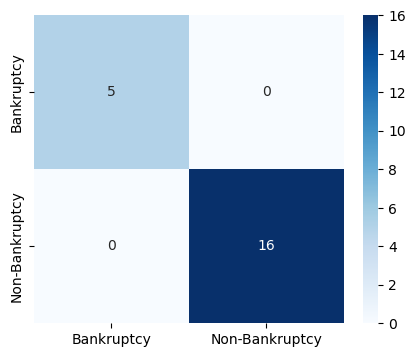

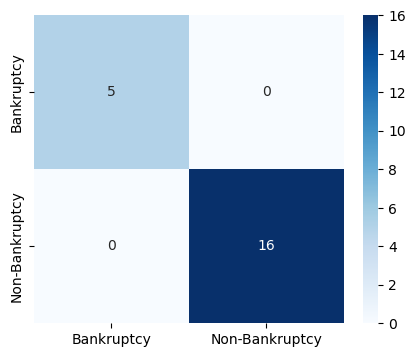

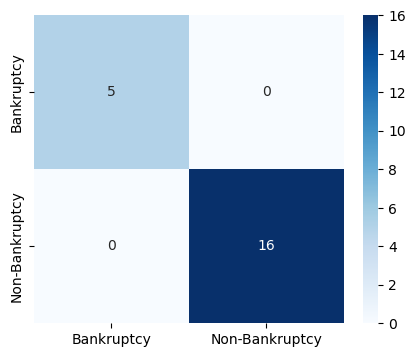

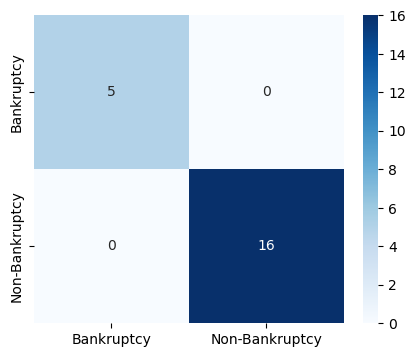

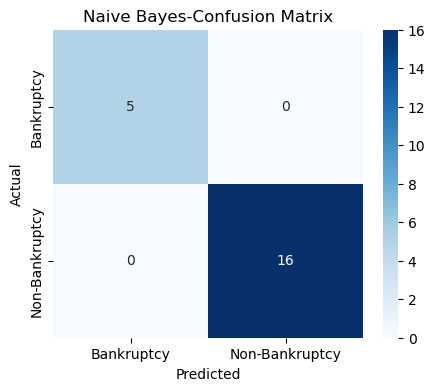

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
models = {
    "Logistic Regression":y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Support Vector Machine": y_pred_knn,
    "Naive Bayes": y_pred_nb
}
for name,pred in models.items():
    cm = confusion_matrix(y_test,pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, 
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=["Bankruptcy","Non-Bankruptcy"],
                yticklabels=["Bankruptcy","Non-Bankruptcy"])
plt.title(f"{name}-Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
     
    

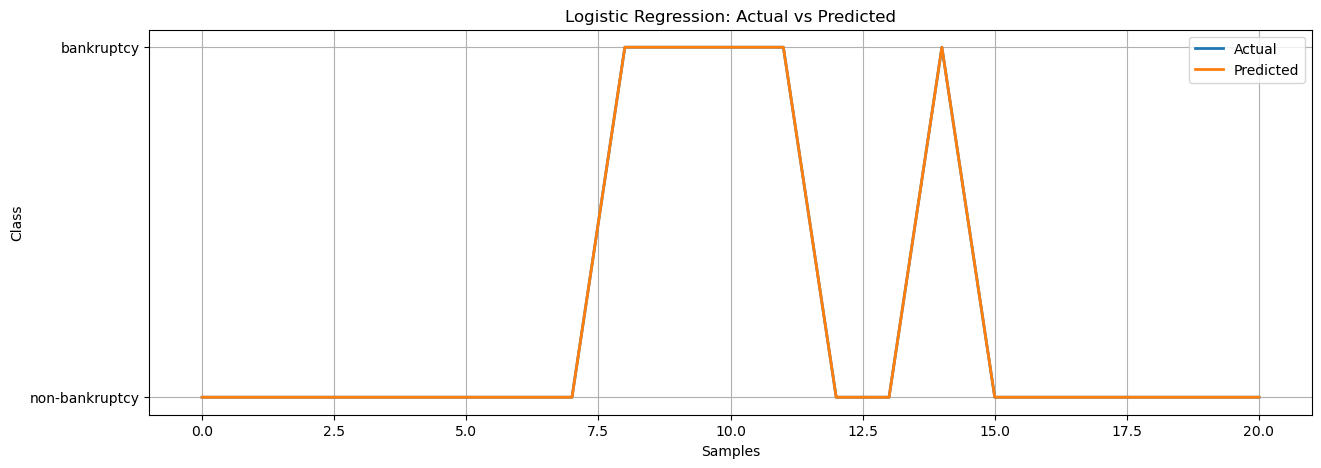

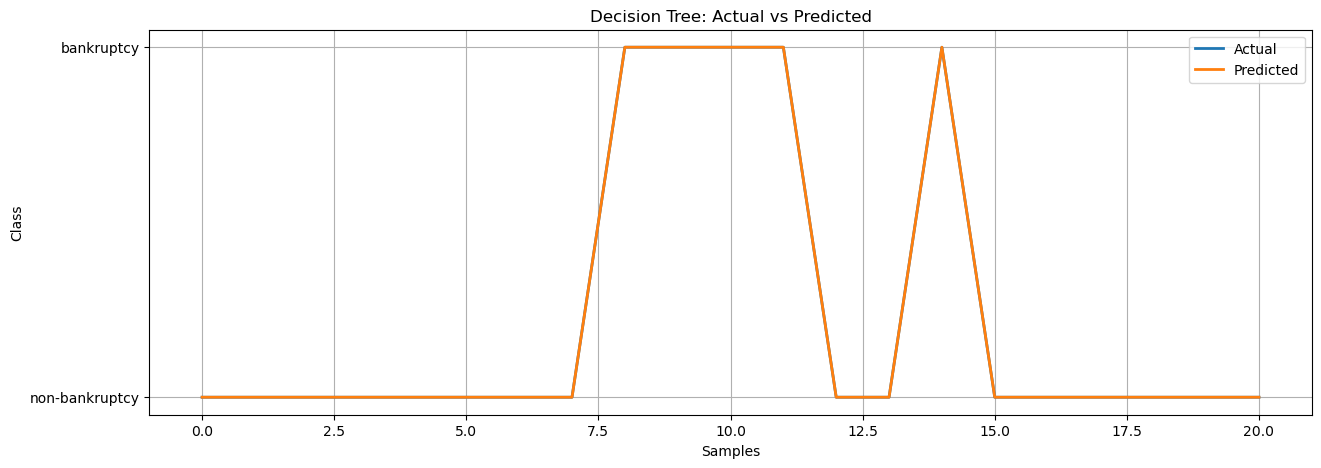

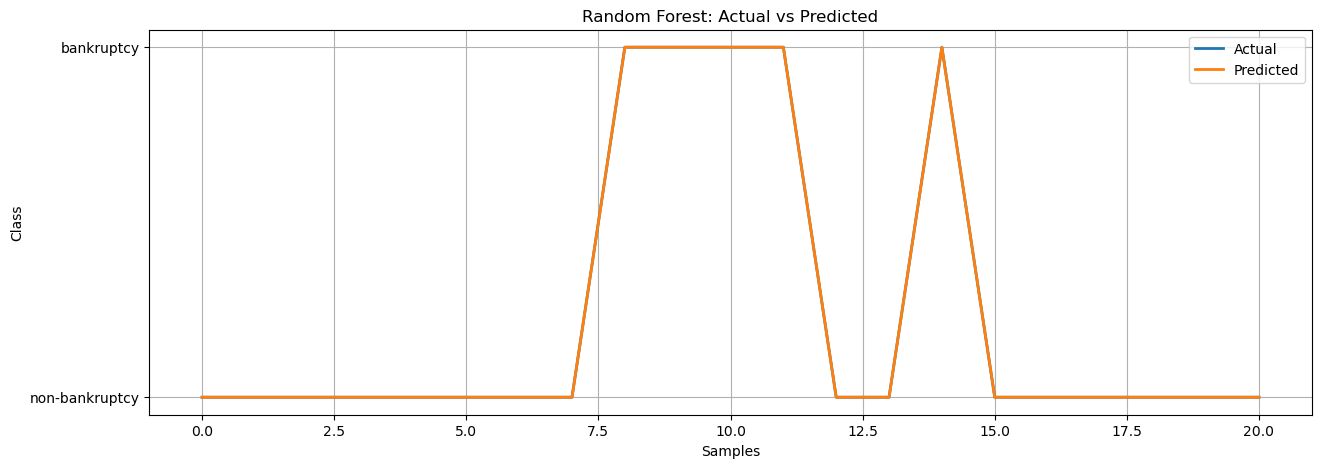

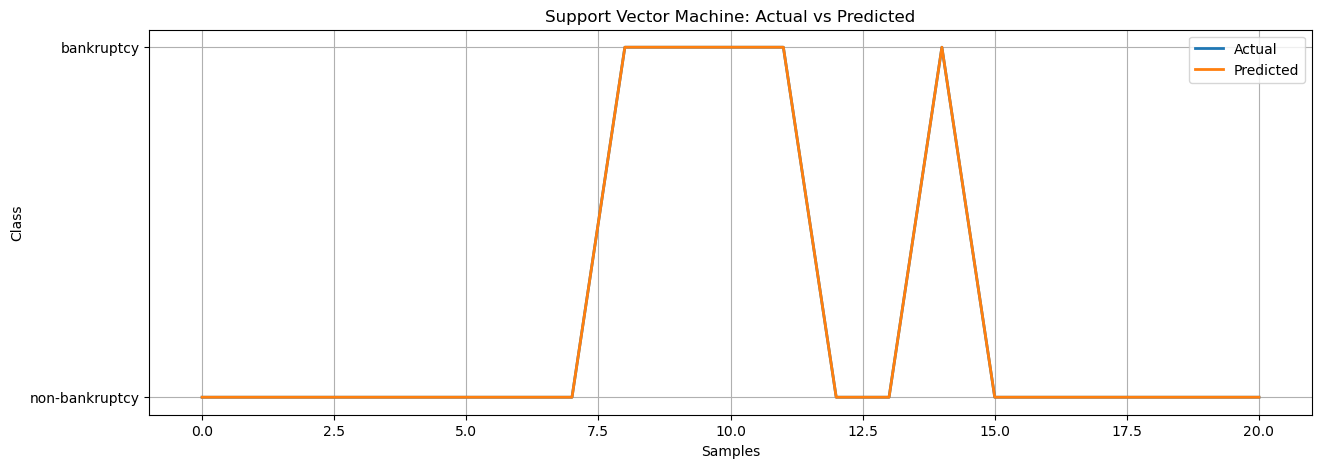

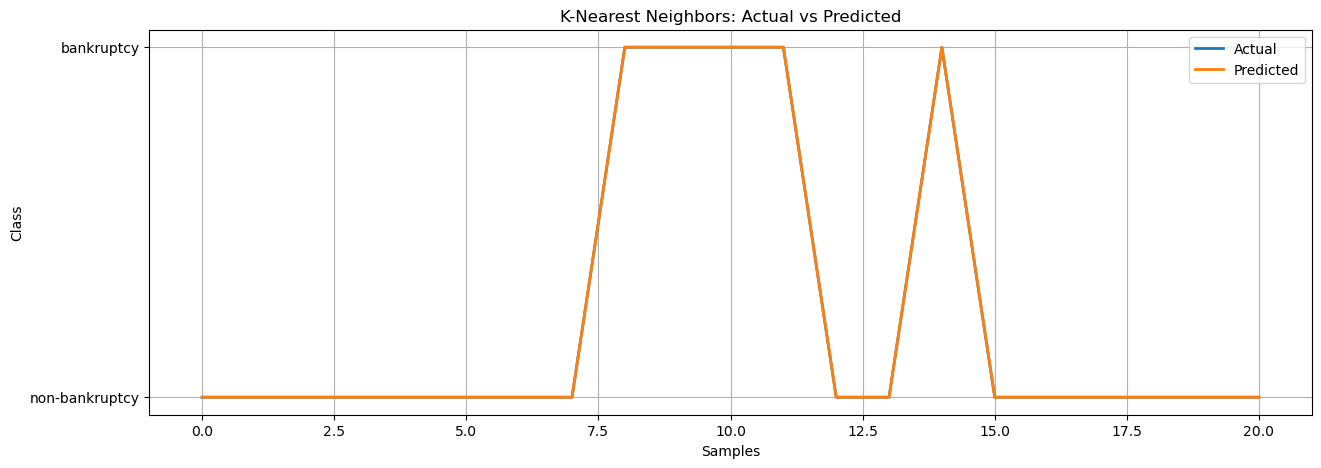

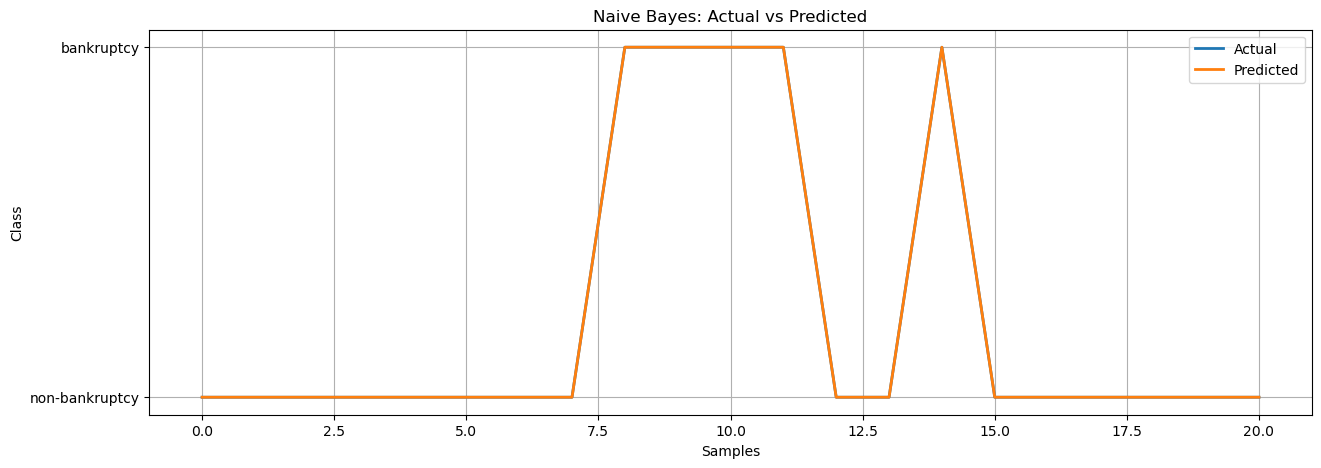

In [69]:
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Support Vector Machine": y_pred_svm,
    "K-Nearest Neighbors": y_pred_knn,
    "Naive Bayes": y_pred_nb
}

for name, pred in models.items():

    plt.figure(figsize=(15,5))

    plt.plot(y_test.values, label="Actual", linewidth=2)
    plt.plot(pred, label="Predicted", linewidth=2)

    plt.title(f"{name}: Actual vs Predicted")
    plt.xlabel("Samples")
    plt.ylabel("Class")

    plt.legend()
    plt.grid(True)

    plt.show()

# Comparing all Models 

In [113]:

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Dictionary of trained models
models = {
    "Logistic Regression": best_lr,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "SVM": best_svm,
    "KNN": best_knn,
    "Naive Bayes": best_nb
}

results = []

for name, model in models.items():

    # Prediction
    y_pred = model.predict(x_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # ROC-AUC (only if available)
    try:
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(x_test)

            # Binary classification
            if y_prob.shape[1] == 2:
                auc = roc_auc_score(
                    y_test,
                    y_prob[:, 1],
                    labels=model.classes_
                )
            else:
                auc = roc_auc_score(
                    y_test,
                    y_prob,
                    multi_class='ovr'
                )
        else:
            auc = "N/A"
    except:
        auc = "N/A"

    results.append({
        "Model": name,
        "Accuracy": round(accuracy,4),
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1 Score": round(f1,4),
        "ROC-AUC": auc
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0
3,SVM,1.0,1.0,1.0,1.0,N/A
4,KNN,1.0,1.0,1.0,1.0,1.0
5,Naive Bayes,1.0,1.0,1.0,1.0,1.0


### Ranking Model


In [116]:
comparison_df["Rank"] = comparison_df["Accuracy"].rank(
    ascending=False,
    method="dense"
).astype(int)

comparison_df = comparison_df.sort_values("Rank")

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Rank
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0,1
1,Decision Tree,1.0,1.0,1.0,1.0,1.0,1
2,Random Forest,1.0,1.0,1.0,1.0,1.0,1
3,SVM,1.0,1.0,1.0,1.0,N/A,1
4,KNN,1.0,1.0,1.0,1.0,1.0,1
5,Naive Bayes,1.0,1.0,1.0,1.0,1.0,1


### Best Model

In [119]:
print("Best Model :", comparison_df.iloc[0]["Model"])
print("Accuracy   :", comparison_df.iloc[0]["Accuracy"])

Best Model : Logistic Regression
Accuracy   : 1.0


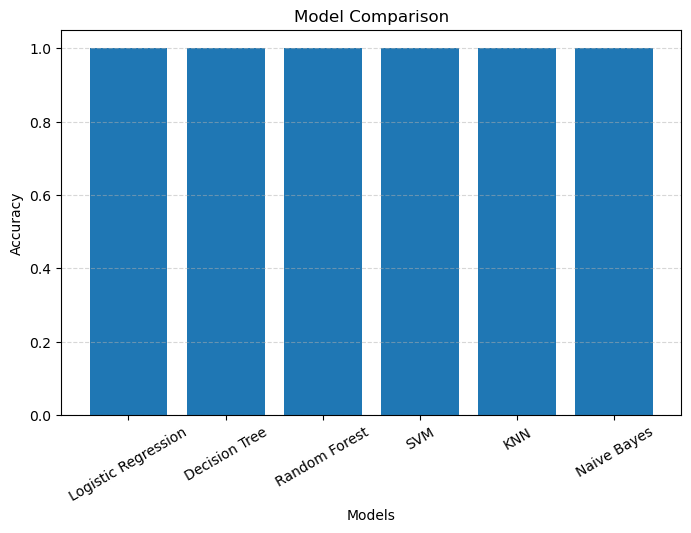

In [121]:
### Accuracy Comparison Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## Model Deployment

In [132]:
## Save the Best Model
print("Best Model :", comparison_df.iloc[0]["Model"])

Best Model : Logistic Regression


In [134]:
import joblib

# Save the best model
joblib.dump(best_rf, "best_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
